## Omnimind Agent System

In [10]:
import os
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool
from typing import TypedDict, List
import ast
import numpy as np

c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### LLM

In [42]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'),
                 model='gpt-4o-mini',
                 temperature=0)

llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000016BB2915090>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000016BB0A922D0>, root_client=<openai.OpenAI object at 0x0000016BB0C37350>, root_async_client=<openai.AsyncOpenAI object at 0x0000016BB291B9D0>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

### Agent State

In [13]:
class AgentState(TypedDict):
    query: str
    tasks: list
    results: list
    final_result: str
    retries: int
    valid: bool
    
AgentState

__main__.AgentState

### Tools

#### Percentage

In [14]:
@tool
def percentage_calc_tool(value: float, percentage: float) -> str:
    '''Calculate Percentage'''
    
    print('\n[TOOL: Percentage Calculator]')
    try:
        return str((value*percentage)/100)
    except Exception as e:
        return f"Claculation Error {e}"

#### Mean

In [15]:
@tool
def calculate_mean_tool(numbers: str) -> str:
    '''Calculates mean of numbers separated by comma'''

    print('\n[TOOL: Calculate Mean]')
    try:
        nums= np.array(numbers.split(',')).astype(float)
        return nums.mean()
    except Exception as e:
        return f'Mean Error {e}'

#### Code Validator

In [16]:
@tool
def code_validator_tool(code: str) -> str:
    '''Validates Python code using AST parsing'''

    print('\n[TOOL: Code Validator]')
    try:
        ast.parse(code)
        return "Code issyntactically valid"
    except SyntaxError as e:
        return f"Syntax Error: {e}"
    except IndentationError as e:
        return f'Indentation Error: {e}'
    except Exception as e:
        print(f'Code Validation Error: {e}')

#### Keyword Extractor

In [17]:
@tool
def keyword_extractor_tool(text: str) -> str:
    '''Extracts first 5 words from the given text'''
    
    print('\n[TOOL: Keyword Extractor]')
    try:
        return ','.join(text.split(',')[:5])
    except Exception as e:
        return f'Keyword Extraction Error: {e}'

### Agents

#### Math Agent

In [18]:
math_agent = create_agent(
    model=llm,
    tools=[percentage_calc_tool],

    system_prompt='''You are a math expert. You always use the given tool when needed.'''
)

#### Coding Agent

In [19]:
coding_agent = create_agent(
    model=llm,
    tools=[code_validator_tool],
    
    system_prompt='''You are a coding expert.
    Generate correct Python code and always validate it with the given tool'''
)

#### Data Analysis Agent

In [20]:
data_agent = create_agent(
    model=llm,
    tools=[calculate_mean_tool, keyword_extractor_tool],
    
    system_prompt='''You are a data analyst. Use the given tools to calculate the mean and to extract the keywords as needed'''
)

#### Summary Agent

In [21]:
summary_agent = create_agent(
    model=llm,
    tools=[],
    
    system_prompt='''You are a helpful Summarize Assistant.
Summarise the given text simply and precisly without losing the main context and the information given in the text. '''
)

#### General Agent

In [22]:
general_agent = create_agent(
    model=llm,
    tools=[],
    
    system_prompt='''You are a helpful assistant. You answer the general queries very briefly with in 100 words.'''
)

### Nodes

In [23]:
def input_guardrails(query):
    print('\n[INPUT GUARDRAILS] ', query)
        
    # Empty check
    if not query.strip():
        # return {'valid': False}
        return False
    
    # Keyword check
    banned_keywords = ['hack', 'attack', 'illegal', 'ignore instructions', 'no restrictions', 'system prompt']
    if any(word in query.lower() for word in banned_keywords):
        # return {'valid': False}
        return False
        
    # return {'valid': True}
    return True

In [24]:
def output_guardrails(result):
    print('\n[OUTPUT GUARDRAILS NODE]')

    # Empty check
    if not result.strip():
        return False
    
    return True

In [25]:
def decomposition_node(query):
    print('\n[DECOMPOSITION NODE]')
    #query = state['query']
    
    try:
        prompt = f'''You are a query decomposition assistant. You have the following tools:
- math: Solves math expressions
- code: Generates Python code
- data: Data Analysis Assistant
- summary: Summarizes text
- general: Answers general queries

QUERY:
{query}

Analyze if the query requires MULTIPLE tools to answer completely.
- If YES, break it into smaller sub-queries, each mapped to a specific tool.
- If NO, return the original query mapped to the appropriate tool.

Return ONLY a Python list of dictionaries. No explanation, no markdown.
Example (multiple): [{{"task": "What is 5+5?", "type": "math"}}, {{"task": "Write a Python code to add two numbers", "type": "code"}}]
Example (single): [{{"task": "What is the capital of France?", "type": "general"}}]
'''

        result = llm.invoke(prompt).content.strip()
        result = ast.literal_eval(result) # convert to list
        print('[DECOMPOSED TASKS]')
        print(result)
        return {'tasks': result}
    except Exception as e:
        print(f'Decompsition Error: {e}')
        return {'tasks': query}

In [38]:
tasks = decomposition_node('what is 23 * 45? Explain AI in brief and what are the latest trends ')
print(type(tasks.get('tasks')))

tks = tasks.get('tasks')
for task in tks:
    print(task.get('task'))


[DECOMPOSITION NODE]
[DECOMPOSED TASKS]
[{'task': 'What is 23 * 45?', 'type': 'math'}, {'task': 'Explain AI in brief', 'type': 'general'}, {'task': 'What are the latest trends in AI?', 'type': 'general'}]
<class 'list'>
What is 23 * 45?
Explain AI in brief
What are the latest trends in AI?


In [85]:
def task_executor_node(state):
    print('\n[TASK EXECUTOR NODE]')
    results = []
    
    try:
        for item in state['tasks']:
            task = item.get('task')
            tool = item.get('type')
            
            print(f'\nRunning Task: {task} using Tool: {tool}')
            
            if (tool == 'code'):
                print('\nCODING AGENT..')
                result = coding_agent.invoke({
                        "messages": [{'role' : 'user' , 'content' : task}]
                })
            elif (tool == 'math'):
                print('\nMATH AGENT..')
                result = math_agent.invoke({
                        "messages": [{'role' : 'user' , 'content' : task}]
                })
            elif (tool == 'data'):
                print('\nDATA AGENT..')
                result = data_agent.invoke({
                        "messages": [{'role' : 'user' , 'content' : task}]
                })
            elif (tool == 'summary'):
                print('\nSUMMARY AGENT..')
                result = summary_agent.invoke({
                        "messages": [{'role' : 'user' , 'content' : task}]
                })
            elif (tool == 'general'):
                print('\nGENERAL AGENT..')
                result = general_agent.invoke({
                        "messages": [{'role' : 'user' , 'content' : task}]
                })
            else:
                print('\nFALLBACK GENERAL AGENT..')
                result = general_agent.invoke({
                        "messages": [{'role' : 'user' , 'content' : task}]
                })
            answer = result['messages'][-1].content
            print(answer)
            results.append(answer)
    except Exception as e:
        results.append(f'Error: {e}')
    return {'results': results}

In [79]:
def combine_node(state):
    print('\n[COMBINE NODE]')
    final_result = '\n'.join(state['results'])
    return {'final_result': final_result}

In [78]:
def validate_node(state):
    print('\n[VALIDATE NODE]')

    res = state.get('final_result', '')
    res = res.strip()
    print(res)

    if res and len(res)>0:
        print('VALID RESULT')
        return {'valid' : True}
    print('INVALID RESULT')
    return {'valid':False}

In [32]:
MAX_RETRIES=2
def retry_node(state):
    print('\n[RETRY NODE]')

    retries = state['retries']
    return {
        'retries' : retries + 1,
    }

In [31]:
def fallback_node(state):
    print('\n[FALLBACK NODE]')
    try:
        result = llm.invoke(state['query']).content
        return {'final_result' : result}
    except Exception as e:
        return {'final_result': 'System Failed Completely'}

### Flow

In [80]:
graph = StateGraph(AgentState)

graph.add_node('decomposition_n', decomposition_node)
graph.add_node('task_executor_n', task_executor_node)
graph.add_node('combine_n', combine_node)
graph.add_node('validate_n', validate_node)
graph.add_node('fallback_n', fallback_node)
graph.add_node('retry_n', retry_node)

In [81]:
graph.set_entry_point('decomposition_n')

graph.add_edge('decomposition_n', 'task_executor_n')
graph.add_edge('task_executor_n', 'combine_n')
graph.add_edge('combine_n', 'validate_n')

graph.add_conditional_edges(
    'validate_n',
    lambda s: 'valid' if s['valid'] else 'retry',
    {
        'valid': END,
        'retry': 'retry_n'
    }
)

graph.add_conditional_edges(
    'retry_n',
    lambda s:'retry' if s['retries'] <= MAX_RETRIES else 'fallback',
    {
        'retry': 'decomposition_n',
        'fallback': 'fallback_n'
    }
)

graph.add_edge('fallback_n', END)

app = graph.compile()

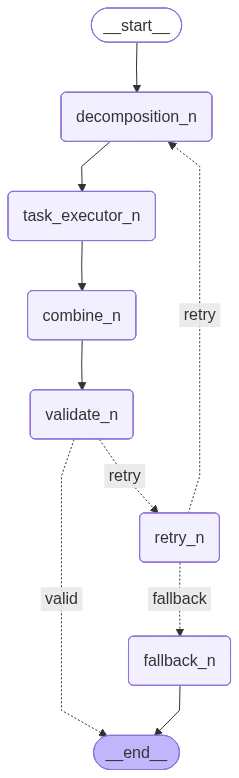

In [37]:
app

### Agent Call

In [76]:
def agent_call():
    while True:
        query = input('Ask (type exit to quit): ')
        
        if query.lower() in ['exit', 'quit', 'stop', 'end']:
            print('exiting......')
            break
        
        if not input_guardrails(query=query):
            return 'Query blocked by input guardrail'
        
        state = app.invoke(
            {'query': query, 'retries': 0}
        )
        print(state)
        
        if not output_guardrails(state['final_result']):
            return 'Invalid output detected'
            
        print(f"\nFinal Answer: {state['final_result']}")

In [58]:
agent_call()


[INPUT GUARDRAILS]   what is 22 * 43

[DECOMPOSITION NODE]
[DECOMPOSED TASKS]
[{'task': '22 * 43', 'type': 'math'}]

[TASK EXECUTOR NODE]
Running Task: 22 * 43 using Tool: math

MATH AGENT..

[COMBINE NODE]

[VALIDATE NODE]
{'query': ' what is 22 * 43', 'tasks': [{'task': '22 * 43', 'type': 'math'}], 'results': ['The result of \\( 22 \\times 43 \\) is \\( 946 \\).'], 'final_result': 'The result of \\( 22 \\times 43 \\) is \\( 946 \\).', 'retries': 0, 'valid': True}

[OUTPUT GUARDRAILS NODE]

Final Answer: The result of \( 22 \times 43 \) is \( 946 \).
exiting......


In [59]:
agent_call()


[INPUT GUARDRAILS]  what is 25% of 80?

[DECOMPOSITION NODE]
[DECOMPOSED TASKS]
[{'task': 'What is 25% of 80?', 'type': 'math'}]

[TASK EXECUTOR NODE]
Running Task: What is 25% of 80? using Tool: math

MATH AGENT..

[TOOL: Percentage Calculator]

[COMBINE NODE]

[VALIDATE NODE]
{'query': 'what is 25% of 80?', 'tasks': [{'task': 'What is 25% of 80?', 'type': 'math'}], 'results': ['25% of 80 is 20.'], 'final_result': '25% of 80 is 20.', 'retries': 0, 'valid': True}

[OUTPUT GUARDRAILS NODE]

Final Answer: 25% of 80 is 20.
exiting......


In [60]:
agent_call()


[INPUT GUARDRAILS]  who won IPL this year?

[DECOMPOSITION NODE]
[DECOMPOSED TASKS]
[{'task': 'who won IPL this year?', 'type': 'general'}]

[TASK EXECUTOR NODE]
Running Task: who won IPL this year? using Tool: general

GENERAL AGENT..

[COMBINE NODE]

[VALIDATE NODE]
{'query': 'who won IPL this year?', 'tasks': [{'task': 'who won IPL this year?', 'type': 'general'}], 'results': ['As of October 2023, the Chennai Super Kings (CSK) won the IPL 2023 title. They defeated the Gujarat Titans in the final.'], 'final_result': 'As of October 2023, the Chennai Super Kings (CSK) won the IPL 2023 title. They defeated the Gujarat Titans in the final.', 'retries': 0, 'valid': True}

[OUTPUT GUARDRAILS NODE]

Final Answer: As of October 2023, the Chennai Super Kings (CSK) won the IPL 2023 title. They defeated the Gujarat Titans in the final.
exiting......


In [82]:
agent_call()


[INPUT GUARDRAILS]  what is 24 * 50 and 23 / 123? Write python code for get api call. Summarize LLM architecture in 50 words. Who is the CM of AP?

[DECOMPOSITION NODE]
[DECOMPOSED TASKS]
[{'task': 'what is 24 * 50', 'type': 'math'}, {'task': 'what is 23 / 123', 'type': 'math'}, {'task': 'Write python code for get api call', 'type': 'code'}, {'task': 'Summarize LLM architecture in 50 words', 'type': 'summary'}, {'task': 'Who is the CM of AP?', 'type': 'general'}]

[TASK EXECUTOR NODE]
Running Task: what is 24 * 50 using Tool: math

MATH AGENT..
The result of \( 24 \times 50 \) is \( 1200 \).
Running Task: what is 23 / 123 using Tool: math

MATH AGENT..
The result of \( \frac{23}{123} \) is approximately \( 0.18699 \) or \( 18.699\% \) when expressed as a percentage. If you need the exact percentage, I can calculate that for you. Would you like me to do that?
Running Task: Write python code for get api call using Tool: code

CODING AGENT..

[TOOL: Code Validator]
Here is the Python cod